In [7]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from phc_nzi.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from phc_nzi.mpb_configurator import *
from phc_nzi.mpi_differential_evolution import MPIdeOptimizator
from phc_nzi.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from phc_nzi.optimization_data_analyzer import OptimizationDataAnalyzer
from phc_nzi.simulation_viewer import SimulationViewer
from phc_nzi.lsf_sweeper import LSFSweeper

import phc_nzi.field_analyzer as fa
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
plt.rcParams["font.size"] = 15

T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "effective_params"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = {
    "k_points_values": [
        mp.Vector3(0.013, 0, 0),
        mp.Vector3(0.2, 0, 0),
    ],
    "k_points_label": [
        "$\Gamma$",
        "$k_x$"
    ],
}
print(k_points)

geom_2D = BaseDielectricDistribution(eps_bulk = eps).make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(eps_bulk = eps, height_slab=0.25).make_C4v_diatomic_B()

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)



configuration_options_2D = dict(
    resolution = 64,
    num_bands=12,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 100,
    extra_runner_command = "fix-hfield-phase fix-efield-phase output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z",
)


configuration_options_slab = dict(
    resolution = 64, 
    num_bands=10,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 20,
    extra_runner_command = "fix-hfield-phase fix-efield-phase output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z",
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_2D)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)


name_2D = name  + "_2D"
name_slab = name + "_slab"



data_rooth = "/work3/s232699/phc_nzi/data/"

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )


simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )




numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


3.0753321000000002
Epsilon of InP:  9.46
{'k_points_values': [Vector3<0.013, 0.0, 0.0>, Vector3<0.2, 0.0, 0.0>], 'k_points_label': ['$\\Gamma$', '$k_x$']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.25)', '(define-param r1 0.1)', '(define-param r2 0.2)']


In [8]:
r1 = 0.24
r2 = 0.23444
print("r2: ", r2)
plt.rcParams["font.size"] = 25


simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)

r2:  0.23444


K-Index: 1, Band: 4, Eps: 0.36795870582254264, Mu: 0.0016574018154766903, Impedance: 0.06711419165367638, N_eff: 0.024695251103212853
K-Index: 1, Band: 6, Eps: 0.0284114166538033, Mu: 0.02143647625880542, Impedance: 0.8686208586442057, N_eff: 0.02467874912912491
K-Index: 2, Band: 4, Eps: (-0.011162239600113508+0j), Mu: (-0.08635776501295717+0j), Impedance: (2.7814741412449817-0j), N_eff: (-0.031047480806096442+0j)
K-Index: 2, Band: 6, Eps: 0.004416711321458115, Mu: 0.21779432461121298, Impedance: 7.022209338192787, N_eff: 0.031015071485644977
K-Index: 3, Band: 4, Eps: (-0.01142677248379606+0j), Mu: (-0.12242786536438743+0j), Impedance: (3.2732437588371988-0j), N_eff: (-0.03740261171623809+0j)
K-Index: 3, Band: 6, Eps: 0.00543184547289494, Mu: 0.256772526751346, Impedance: 6.875441229770467, N_eff: 0.03734633431808393
K-Index: 4, Band: 4, Eps: (-0.014087429067720173+0j), Mu: (-0.13594308394737548+0j), Impedance: (3.106437983196809-0j), N_eff: (-0.043761724741556755+0j)
K-Index: 4, Band:

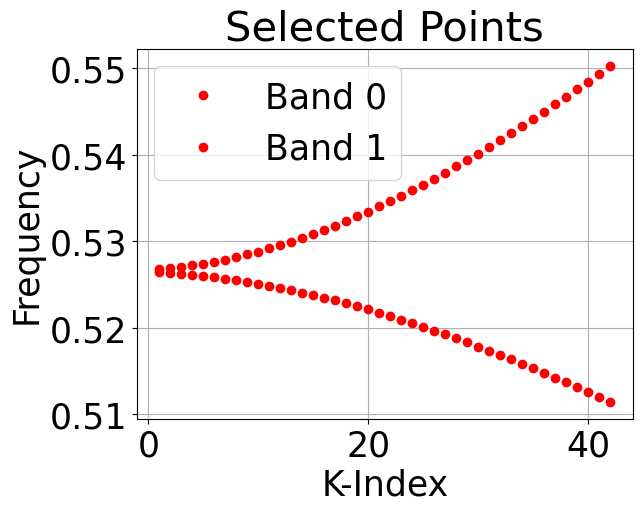

In [3]:

analyzer = fa.FieldAnalyzer(simulation_2D, [4,  6], "te", "x")
data = analyzer.get_eps_mu_impedance_neff("y", "z", plot = True)



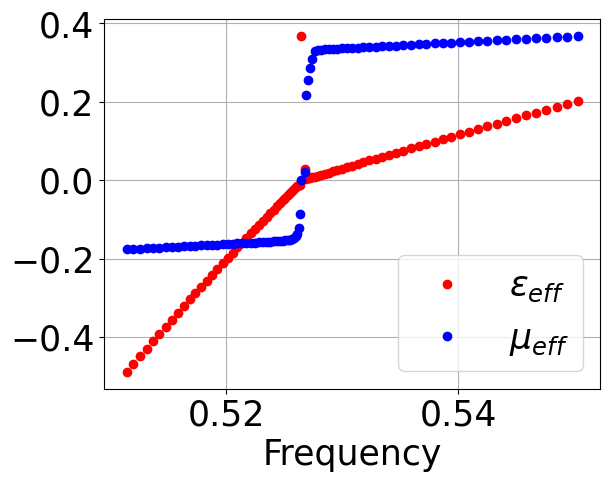

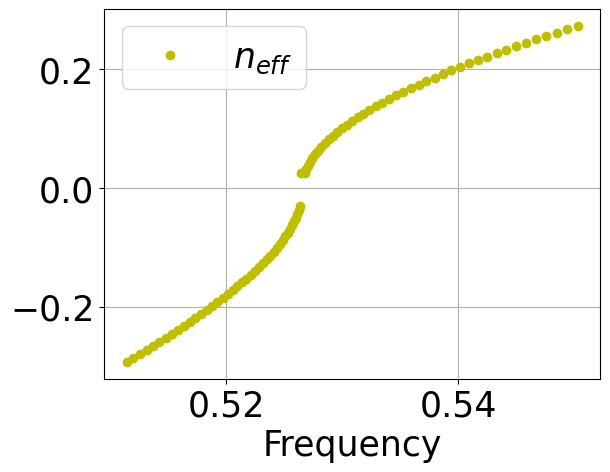

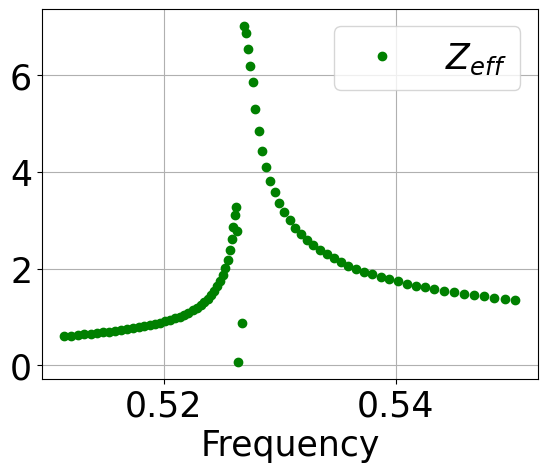

In [10]:
plt.figure()

analyzer.plot_eps_vs_freqs()

analyzer.plot_mu_vs_freqs()
plt.show()
plt.figure()
analyzer.plot_neff_vs_freqs()

plt.figure()
analyzer.plot_impedance_vs_freqs()


# plt.hlines(1/n_InP, 0, 1.5, color="red", linestyle="--", label="InP")

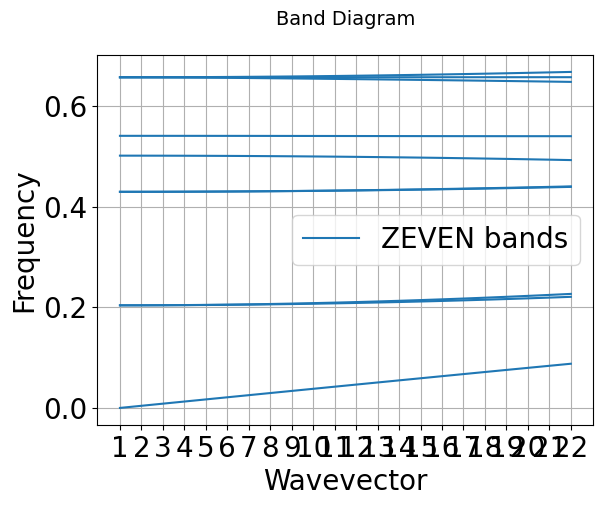

In [5]:
r1 = 0.24
r2 = 0.2390
hh=0.25
plt.rcParams["font.size"] = 20
#simulation_slab.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh), LSFOptions=lsf_config)
visualizer_slab = SimulationViewer(simulation_slab)
visualizer_slab.plot_band_diagram("zeven")

FileNotFoundError: Field file not found: /work3/s232699/phc_nzi/data/effective_params_slab/effective_params_slab-e.v.k01.b08.y.zeven.h5

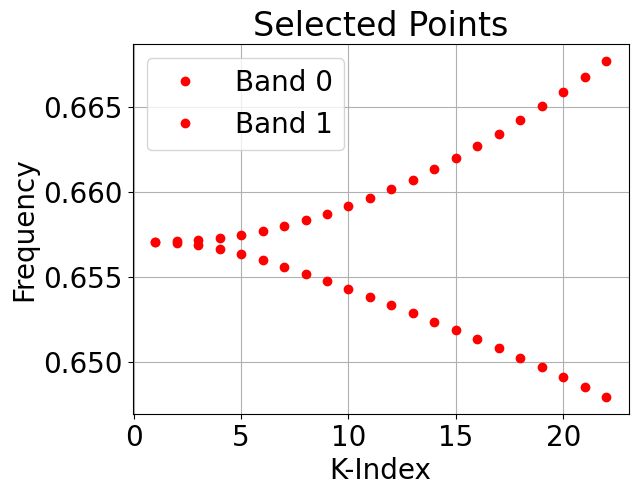

In [ ]:
import phc_nzi.field_analyzer as fa

analyzer = fa.FieldAnalyzer(simulation_slab, [8,  10], "zeven", "x")



